# Tunisia Medical Access — Supply vs Demand

**Portfolio project — private healthcare access inequality in Tunisia.**

Two datasets, two sides of one market:

- **Supply** — `doctors.csv`: 9,851 **private-practice** doctors (own cabinet) from the CNOM registry via medline.tn. *Public-hospital-only doctors are not included.*
- **Demand** — `gsc_*.csv`: 16 months of Google Search Console — what people searched to find the site.

**Headline question:** *where is search demand high but private-doctor supply low?* —
medical deserts validated by real public demand.

> The raw doctor file carries phone/email PII and is gitignored — this notebook runs
> locally against `data/raw/`.

In [2]:
import unicodedata
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (9, 4)
RAW = Path('..') / 'data' / 'raw'

def strip_accents(s):
    """lowercase + remove diacritics, for robust FR/AR-translit matching."""
    s = str(s).lower()
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

## 1 · Supply — the doctor directory

Load it, see its shape, and profile the missingness (this is real registry data —
cleaning it *is* the job).

In [3]:
docs = pd.read_csv(RAW / 'doctors.csv')
print(docs.shape)
docs.head(3)

(9851, 13)


,slug,name,firstName,lastName,nameAr,specialtySlug,gouvernoratSlug,delegationGov,delegationSlug,address,phone,email,mapQuery
0,henda-kachouri-ep-chakchouk,Dr. Henda Kachouri Ep Chakchouk,Henda,Kachouri Ep Chakchouk,NaN,pediatrie,benarous,benarous,el-mourouj,Centre Médical Baya au Dessus de Carrefour 2èm...,22 175 700,henda_23@yahoo.fr,place_id:ChIJAf9oMQA3_RIRpQVtEZhKzCY
1,khalifa-selmi,Dr. Khalifa Selmi,Khalifa,Selmi,خليــفـة السَّــــالْـمِــي,cardiologie,benarous,tunis,el-kram,"151, Avenue Habib Bourguiba, Cabinet 7 au 4 Èm...",98 485 726,khalifa.selmi@gmail.com,"36.8308306,10.314816"
2,khaoula-tarhouni,Dr. Khaoula Tarhouni,Khaoula,Tarhouni,NaN,orl,benarous,benarous,el-mourouj,Cabinet B2- 10 Bloc B- Centre Médical Kmar- Mo...,92 102 717,khaoula.orl@gmail.com,"36.7155966,10.2160303"


In [4]:
# Missingness — empty CSV fields read as NaN. The gaps tell a story:
# 26% have no geocode, 10% no email, only ~9% have an Arabic name.
missing = (docs.isna().mean() * 100).round(1)
missing[missing > 0].sort_values(ascending=False)

nameAr            90.6
mapQuery          26.4
delegationGov     16.3
delegationSlug    16.3
email             10.3
phone              2.4
dtype: float64

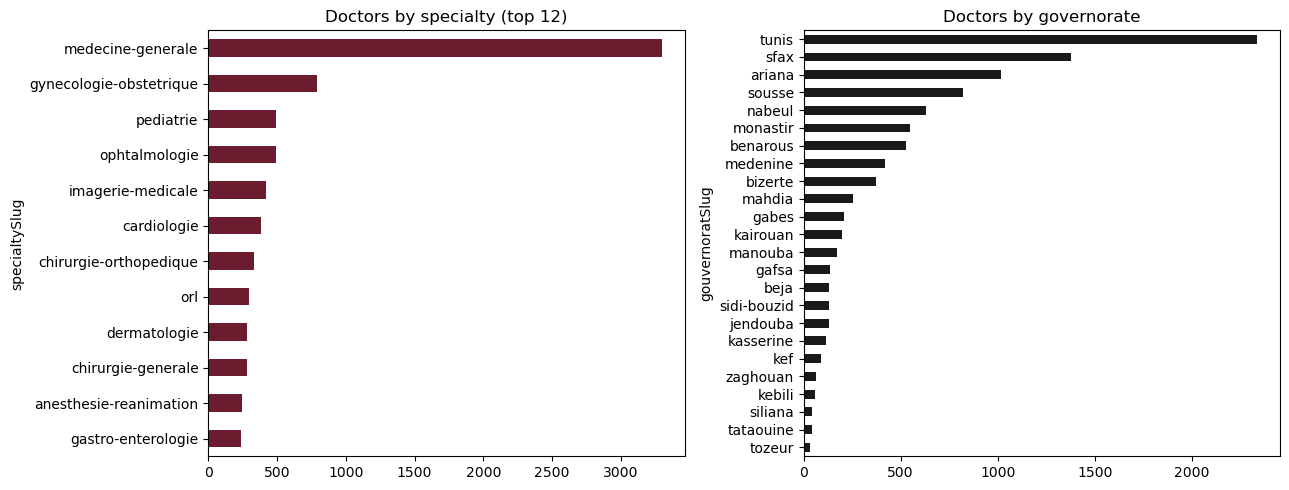

In [5]:
# Supply by specialty (top 12) and by governorate.
by_spec = docs['specialtySlug'].value_counts()
by_gov  = docs['gouvernoratSlug'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
by_spec.head(12).iloc[::-1].plot.barh(ax=axes[0], color='#6B1D2F')
axes[0].set_title('Doctors by specialty (top 12)')
by_gov.iloc[::-1].plot.barh(ax=axes[1], color='#1a1a1a')
axes[1].set_title('Doctors by governorate')
plt.tight_layout(); plt.show()

Raw counts are dominated by Tunis (2,338) vs Tozeur (33) — but population differs
hugely too. **Per-capita** density (next step: join INS population) is the honest
measure. See `data/external/README.md` for the population + GeoJSON sources.

## 2 · Demand — Google Search Console

What patients actually typed. Each query has clicks, impressions, CTR and average
Google position.

In [6]:
q     = pd.read_csv(RAW / 'gsc_queries.csv')
pages = pd.read_csv(RAW / 'gsc_pages.csv')
print(f'{len(q):,} queries | {int(q.clicks.sum()):,} clicks | {int(q.impressions.sum()):,} impressions')
q.sort_values('impressions', ascending=False).head(8)

7,881 queries | 436 clicks | 29,510 impressions


,query,clicks,impressions,ctr,position
73,dermatologue,1,412,0.002427,8.225728
321,ophtalmologue,1,195,0.005128,10.174359
6,dr mohamed osman kilani,3,135,0.022222,7.555556
1271,dermatologue autour de moi,0,99,0.000000,9.777778
12,cardiologue tunis,2,94,0.021277,10.031915
298,mohamed osman kilani,1,91,0.010989,7.923077
6675,pneumologue,0,83,0.000000,10.048193
241,gamara mohamed ali,1,77,0.012987,10.727273


### Query intent — branded vs generic

Two kinds of search:
- **Branded** — a specific person (`dr fatma mghaieth`). Demand for *one* doctor.
- **Generic** — a specialty + a place (`cardiologue tunis`). Demand for *access* — this
  is the signal we join against supply.

We tag generic queries by detecting a specialty term **and** a governorate name.

In [7]:
# governorate keyword variants: base = slug spaced, plus a few overrides
overrides = {
    'benarous': ['ben arous'], 'sidibouzid': ['sidi bouzid'],
    'kef': ['le kef', 'kef'], 'manouba': ['manouba', 'mannouba'],
}
gov_kw = {g: overrides.get(g, [g.replace('-', ' ')]) for g in by_gov.index}

SPEC_TERMS = ['cardiologue', 'dentiste', 'dermatologue', 'pediatre',
    'gynecologue', 'ophtalmologue', 'ophtalmo', 'psychiatre', 'neurologue',
    'radiologue', 'urologue', 'rhumatologue', 'endocrinologue', 'generaliste',
    'medecin', 'chirurgien', 'pneumologue', 'orthopediste', 'orl', 'dentaire']

q['norm'] = q['query'].map(strip_accents)
q['has_spec'] = q['norm'].apply(lambda s: any(t in s for t in SPEC_TERMS))

def match_gov(s):
    for g, kws in gov_kw.items():
        if any(strip_accents(k) in s for k in kws):
            return g
    return None

q['gov'] = q['norm'].apply(match_gov)
q['is_generic'] = q['has_spec'] & q['gov'].notna()
print('generic specialty+city queries:', int(q.is_generic.sum()))
q[q.is_generic].sort_values('impressions', ascending=False)\
    .head(10)[['query', 'clicks', 'impressions', 'position']]

generic specialty+city queries: 322


,query,clicks,impressions,position
12,cardiologue tunis,2,94,10.031915
1308,dermatologue tunis,0,74,10.405405
244,gynécologue sfax,1,73,9.068493
101,dr arij ezzouhour yahyaoui – médecine interne ...,1,67,8.044776
6813,rhumatologue tunis,0,45,11.155556
6703,psychiatre nabeul,0,41,8.902439
36,psychiatre tunis,2,26,4.230769
6474,neurologue tunis,0,21,7.238095
5020,gynécologue sousse,0,19,10.105263
6804,rhumatologue ariana,0,19,9.789474


## 3 · The gap — demand pressure per doctor

For each governorate: total search impressions (any geo query) ÷ doctor count.
A **high** ratio = lots of search interest chasing few doctors → desert pressure.

In [8]:
demand = (q[q.gov.notna()].groupby('gov')['impressions'].sum()
            .rename('search_impressions'))
supply = by_gov.rename('doctors')

gap = pd.concat([supply, demand], axis=1).fillna(0)
gap['impr_per_doctor'] = (gap.search_impressions / gap.doctors).round(2)
gap = gap.sort_values('impr_per_doctor', ascending=False)
gap.head(10)

,doctors,search_impressions,impr_per_doctor
jendouba,128,90.0,0.70
kef,89,50.0,0.56
manouba,173,79.0,0.46
tunis,2338,748.0,0.32
sfax,1380,416.0,0.30
bizerte,372,98.0,0.26
sousse,819,198.0,0.24
nabeul,631,136.0,0.22
gabes,208,44.0,0.21
kairouan,195,33.0,0.17


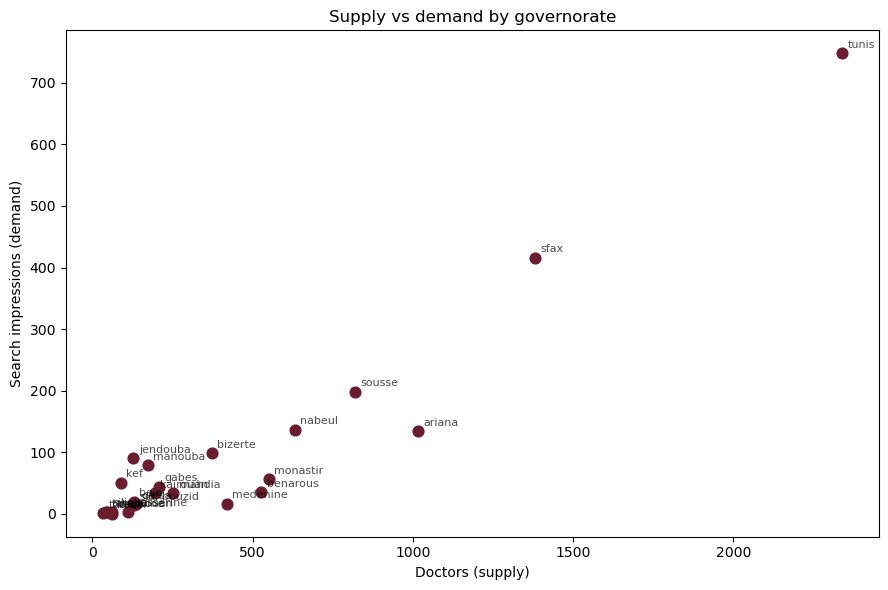

In [9]:
# Visualise the gap: supply (x) vs demand (y); points far above the
# trend = under-supplied for their demand.
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(gap.doctors, gap.search_impressions, s=60, color='#6B1D2F')
for g, r in gap.iterrows():
    ax.annotate(g, (r.doctors, r.search_impressions),
                fontsize=8, alpha=0.7, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Doctors (supply)'); ax.set_ylabel('Search impressions (demand)')
ax.set_title('Supply vs demand by governorate')
plt.tight_layout(); plt.show()

## Next steps

This starter establishes the supply, demand, and the join. To turn it into the
flagship project:

1. **Per-capita density** — join INS population → doctors per 100k (replaces raw counts).
2. **Choropleth maps** — `geopandas` + `tunisia_governorates.geojson`: map the desert score.
3. **Go finer** — repeat at the *delegation* level (228 zones) for sharper deserts.
4. **Specialty-level gaps** — which specialty is missing where (e.g. 0 cardiologists / 100k).
5. **Inequality metric** — a Gini coefficient of access across regions.
6. **Deploy** — a Streamlit dashboard to filter by specialty/region.

*Caveats to state in the writeup:* GSC hides low-volume queries (privacy threshold) and
caps history at ~16 months, so demand is a strong **signal**, not a full census.